Each cell of this notebook after the initialisation cell provides a different analysis and/or plot of the spike data exported from the previous notebook (main_part1).

# STEP 0: INITIALISATION

Run this code block once per session, to initialise and import modules
and get a list of JSON files created in `main_part1.ipynb`.

In [1]:
import hff_analysis

import matplotlib.pyplot as plt
import pathlib

# User defined variables
length_predictor = 'weight'
load_jsons = 'latest'
slowest_on_top = False
save_plots = True
save_stats = True
stats_folder = '.\\outputs\\stats\\'


### User does not need to modify below this line ###

spikes_df, new = hff_analysis.spikes_table(load_jsons)

# Exclude nine-one mechanical epochs from HFF02-1, HFF05-1, and HFF16-1
spikes_df = spikes_df.loc[
    ((spikes_df['Unit ID']!='hff02_1') &
     (spikes_df['Unit ID']!='hff05_1') &
     (spikes_df['Unit ID']!='hff16_1')) |
    (spikes_df['Test'] != 'nine-one') |
    (spikes_df['Epoch Stimulus'] != 'mechanical')
]
# Exclude HFF05-1 long-duration
spikes_df = spikes_df.loc[
    (spikes_df['Unit ID']!='hff05_1') |
    (spikes_df['Test'] != 'long-duration')
]
# Exclude HFF13-2 amplitude
spikes_df = spikes_df.loc[
    (spikes_df['Unit ID']!='hff13_2') |
    (spikes_df['Test'] != 'amplitude')
]
if new:
    for unit_id in spikes_df['Unit ID'].unique():
        unit_df = spikes_df.loc[spikes_df['Unit ID'] == unit_id]
        hff_analysis.plot_unit_inspection_figs(unit_df, unit_id)
        plt.close()

initial_properties = hff_analysis.initial_properties(
    load_jsons,
    spikes_df,
    length_predictor,
    'electrical'
)
conduction_velocities = {
    k: v.conduction_velocity for k,v in initial_properties.items()
}

cv_norm = hff_analysis.normalise_conduction_velocity((10, 35))

spikes_df

Trying to load `spikesdf` from file...
spikesdf_3.0.0.json: Compatible
`spikesdf` loaded from file: spikesdf_3.0.0.json
Contains 18 units:
hff02_1
hff02_2
hff03_3
hff05_1
hff05_2
hff08_1
hff10_1
hff11_1
hff11_2
hff11_3
hff12_1
hff13_2
hff15_1
hff16_1
hff19_2
hff19_3
hff19_5
hff20_1

hff05-2_[1-0]_freq: 0.0101
Highest ISI result: 0.010050251256281407

Trying to load `initialprops` from file...
initialprops_3.0.0.json: Compatible
`initialprops` loaded from file: initialprops_3.0.0.json


,Animal ID,Sex,Position,Unit ID,Unit Type,Test,Test Stimulus,Test Frequency,Minor Test Frequency,Test Amplitude,...,Phase,Epoch Stimulus,Phase ID,Epoch Number,Epoch ID,Epoch Frequency,Epoch Amplitude,Total Epochs,Latency (ms),Size (μV)
0,hff02,M,1,hff02_1,FA,frequency,electrical,10.0,-1.0,1.0,...,conditioning,electrical,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,0,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,10.0,1.0,30,2.775,83.932808
1,hff02,M,1,hff02_1,FA,frequency,electrical,10.0,-1.0,1.0,...,conditioning,electrical,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,1,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,10.0,1.0,30,2.750,91.054566
2,hff02,M,1,hff02_1,FA,frequency,electrical,10.0,-1.0,1.0,...,conditioning,electrical,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,2,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,10.0,1.0,30,2.775,85.651492
3,hff02,M,1,hff02_1,FA,frequency,electrical,10.0,-1.0,1.0,...,conditioning,electrical,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,3,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,10.0,1.0,30,2.775,83.568945
4,hff02,M,1,hff02_1,FA,frequency,electrical,10.0,-1.0,1.0,...,conditioning,electrical,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,4,hff02_1_frequency_electrical_10.0~-1.0_1.0_0_c...,10.0,1.0,30,2.750,95.287079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214009,hff20,F,1,hff20_1,SA,nine-one,mechanical,90.0,10.0,1.0,...,recovery,mechanical,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,14,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,1.0,1.0,19,4.150,199.790028
214010,hff20,F,1,hff20_1,SA,nine-one,mechanical,90.0,10.0,1.0,...,recovery,mechanical,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,15,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,1.0,1.0,19,4.200,198.030806
214011,hff20,F,1,hff20_1,SA,nine-one,mechanical,90.0,10.0,1.0,...,recovery,mechanical,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,16,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,1.0,1.0,19,4.150,209.098487
214012,hff20,F,1,hff20_1,SA,nine-one,mechanical,90.0,10.0,1.0,...,recovery,mechanical,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,17,hff20_1_nine-one_mechanical_90.0~10.0_1.0_0_re...,1.0,1.0,19,4.150,200.637432


# PAPER PLOTS

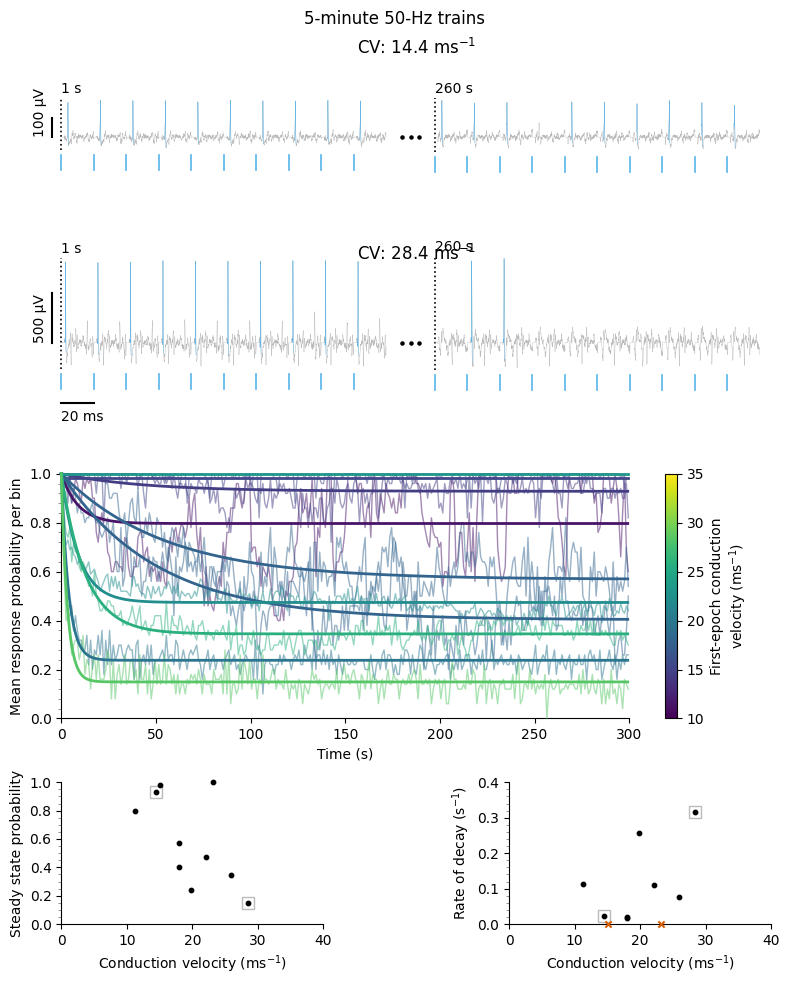

In [2]:
# User defined variables
trace_units = ('hff19_5', 'hff16_1')
slow_trace = ('hff19_pos5_long-duration', 0)
slow_spikes = 'spikes_hff19-5_[0-0]_long_v3.0.0.json'
slow_yspacing = 800
slow_yscale = 100
fast_trace = ('hff16_pos1_long-duration', 0)
fast_spikes = 'spikes_hff16-1_[0-0]_long_v3.0.0.json'
fast_y_spacing = 1500
fast_yscale = 500
trace_times = (1, 260)
constant_units = ['hff05_2', 'hff19_2']
rolling_bins = False


### User does not need to modify below this line ###

# Figure 2
fitted_df, binned_df = hff_analysis.longduration_probability(
    spikes_df,
    conduction_velocities,
    cv_norm,
    trace_units,
    slow_trace,
    slow_spikes,
    slow_yspacing,
    slow_yscale,
    fast_trace,
    fast_spikes,
    fast_y_spacing,
    fast_yscale,
    trace_times,
    constant_units,
    slowest_on_top,
    rolling_bins,
    save_plots
)

if save_stats:
    fitted_name = '1_fitted-values.csv'
    binned_name = '1_binned-values.csv'
    try:
        fitted_df.to_csv(stats_folder+fitted_name)
        binned_df.to_csv(stats_folder+binned_name)
    except OSError:
        # Make directories if they don't exist
        pathlib.Path(stats_folder).mkdir(parents=True, exist_ok=True)
        fitted_df.to_csv(stats_folder+fitted_name)
        binned_df.to_csv(stats_folder+binned_name)

  adjustable: {'box', 'datalim'}
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  anchor: (float, float) or {'C', 'SW', 'S', 'SE', 'E', 'NE', ...}
  animated: bool
  aspect: {'auto', 'equal'} or float
  autoscale_on: bool
  autoscalex_on: unknown
  autoscaley_on: unknown
  axes_locator: Callable[[Axes, Renderer], Bbox]
  axisbelow: bool or 'line'
  box_aspect: float or None
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  facecolor or fc: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  forward_navigation_events: bool or "auto"
  frame_on: bool
  gid: str
  in_layout: bool
  label: object
  mouseover: bool
  navigate: bool
  navigate_mode: unknown
  path_effects: list of `.AbstractPathEffect`
  picker: None or bool or float or c

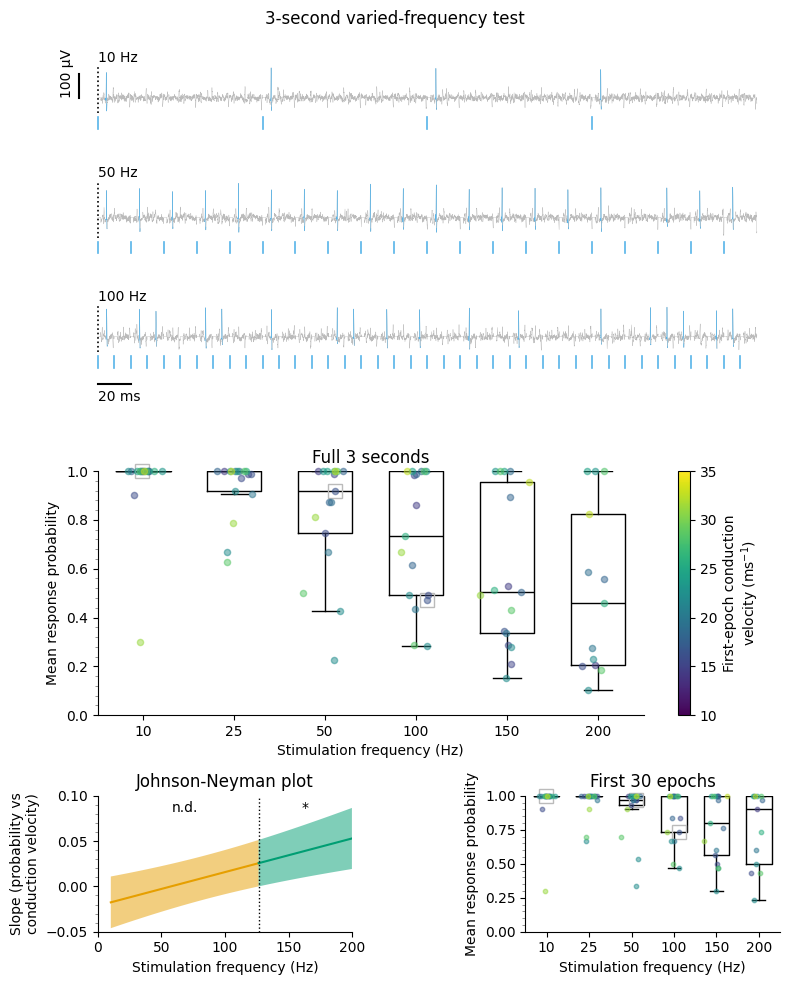

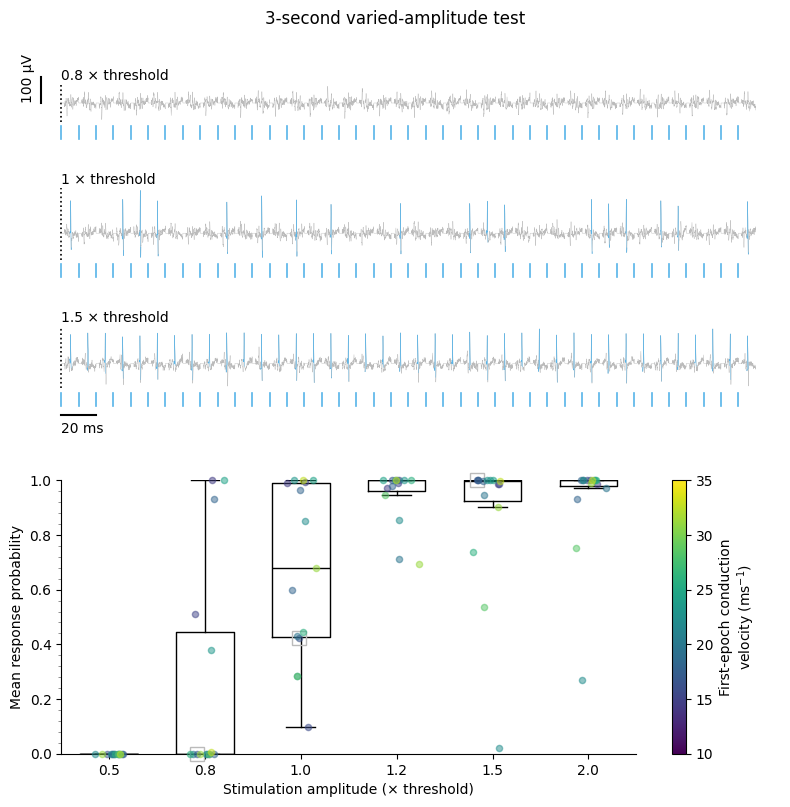

In [3]:
# User defined variables
trace_unit = 'hff05_1'
frequency_trace = ('hff05_pos1_freqsweep2', 0)
frequency_spikes = 'spikes_hff05-1_[1-0]_freq_v3.0.0.json'
frequency_trials = (
    (100, 1.79),
    (50, 1.48),
    (10, 0.9)
)
amplitude_trace = ('hff05_pos1_amplsweep2', 0)
amplitude_spikes = 'spikes_hff05-1_[1-0]_ampl_v3.0.0.json'
amplitude_trials = (
    (1.5, 1.19),
    (1, 0.49),
    (0.8, 0.39)
)
yspacing = 500
yscale = 100
first_n = None
last_s = None
extend_jn_boundaries = True


### User does not need to modify below this line ###

# Figures 3-4
frequency_df, amplitude_df = hff_analysis.sweeps_probability(
    spikes_df,
    conduction_velocities,
    cv_norm,
    trace_unit,
    frequency_trace,
    frequency_spikes,
    frequency_trials,
    yspacing,
    yscale,
    amplitude_trace,
    amplitude_spikes,
    amplitude_trials,
    yspacing,
    yscale,
    first_n,
    extend_jn_boundaries,
    slowest_on_top,
    save_plots
)

if save_stats:
    frequency_name = '2_frequency-values.csv'
    amplitude_name = '2_amplitude-values.csv'
    try:
        frequency_df.to_csv(stats_folder+frequency_name)
        amplitude_df.to_csv(stats_folder+amplitude_name)
    except OSError:
        # Make directories if they don't exist
        pathlib.Path(stats_folder).mkdir(parents=True, exist_ok=True)
        frequency_df.to_csv(stats_folder+frequency_name)
        amplitude_df.to_csv(stats_folder+amplitude_name)

  adjustable: {'box', 'datalim'}
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  anchor: (float, float) or {'C', 'SW', 'S', 'SE', 'E', 'NE', ...}
  animated: bool
  aspect: {'auto', 'equal'} or float
  autoscale_on: bool
  autoscalex_on: unknown
  autoscaley_on: unknown
  axes_locator: Callable[[Axes, Renderer], Bbox]
  axisbelow: bool or 'line'
  box_aspect: float or None
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  facecolor or fc: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  forward_navigation_events: bool or "auto"
  frame_on: bool
  gid: str
  in_layout: bool
  label: object
  mouseover: bool
  navigate: bool
  navigate_mode: unknown
  path_effects: list of `.AbstractPathEffect`
  picker: None or bool or float or c

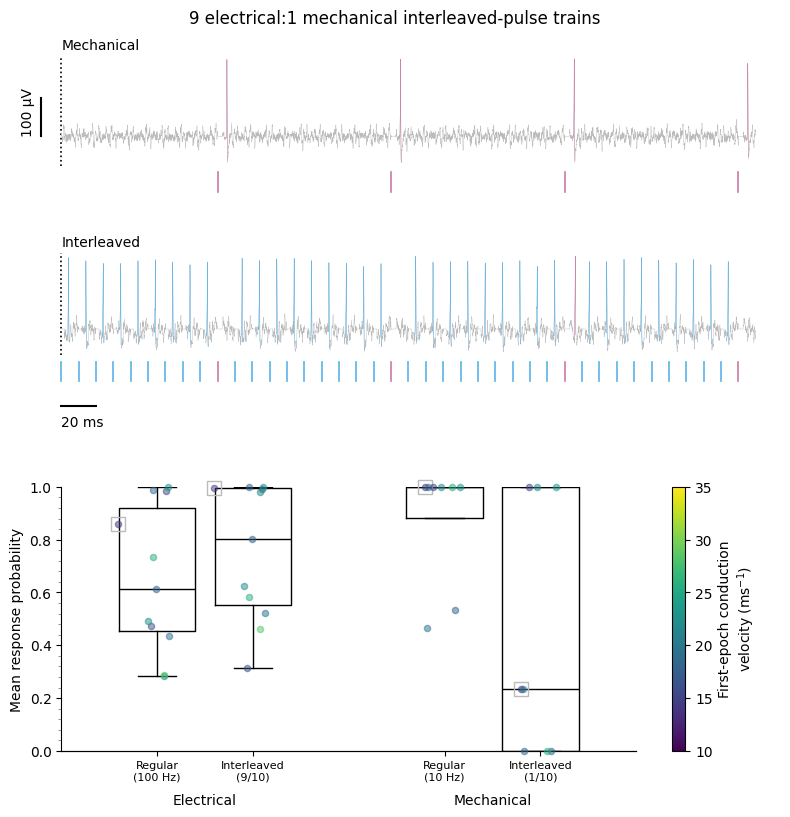

In [4]:
# User defined variables
trace_unit = 'hff19_5'
nineone_trace = ('hff19_pos5_nine-one', 0)
nineone_spikes = 'spikes_hff19-5_[0-0]_nine_v3.0.0.json'
nineone_time = 0.8
mech_trace = ('hff19_pos5_freqsweep', 0)
mech_spikes = 'spikes_hff19-5_[0-0]_freq_v3.0.0.json'
mech_time = 0
yspacing = 500
yscale = 100


### User does not need to modify below this line ###

# Figure 5
nineone_df = hff_analysis.nineone_probability(
    spikes_df,
    conduction_velocities,
    cv_norm,
    trace_unit,
    nineone_trace,
    nineone_spikes,
    nineone_time,
    mech_trace,
    mech_spikes,
    mech_time,
    yspacing,
    yscale,
    slowest_on_top,
    save_plots
)

if save_stats:
    nineone_name = '3_nineone-values.csv'
    try:
        nineone_df.to_csv(stats_folder+nineone_name)
    except OSError:
        # Make directories if they don't exist
        pathlib.Path(stats_folder).mkdir(parents=True, exist_ok=True)
        nineone_df.to_csv(stats_folder+nineone_name)

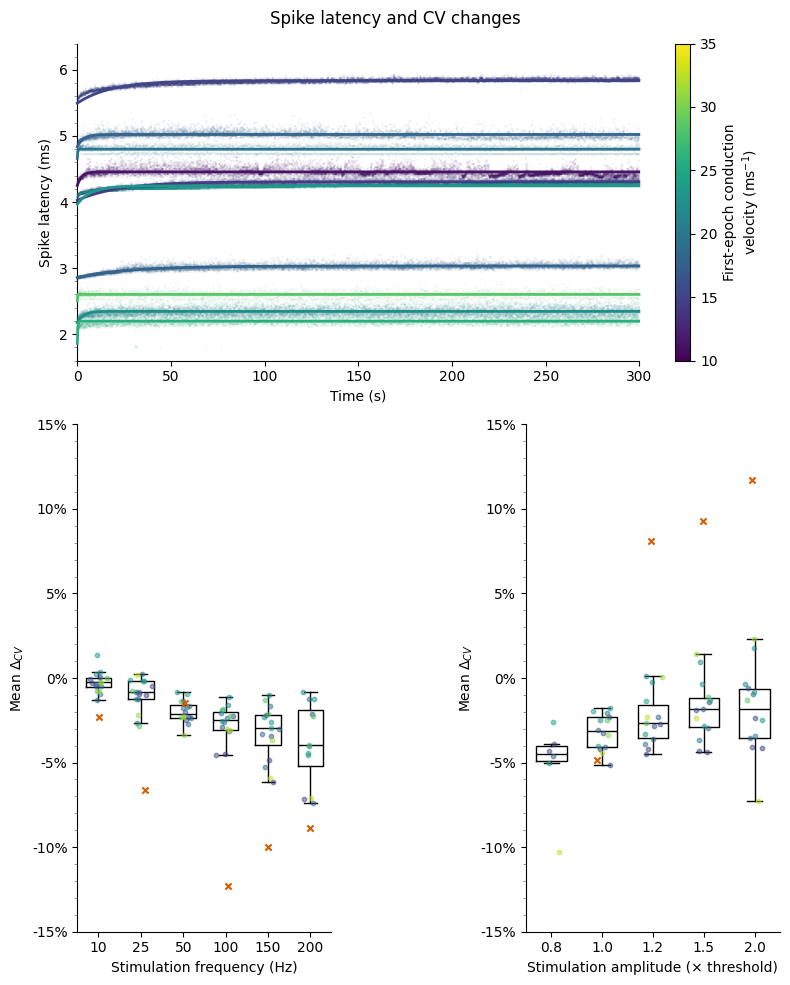

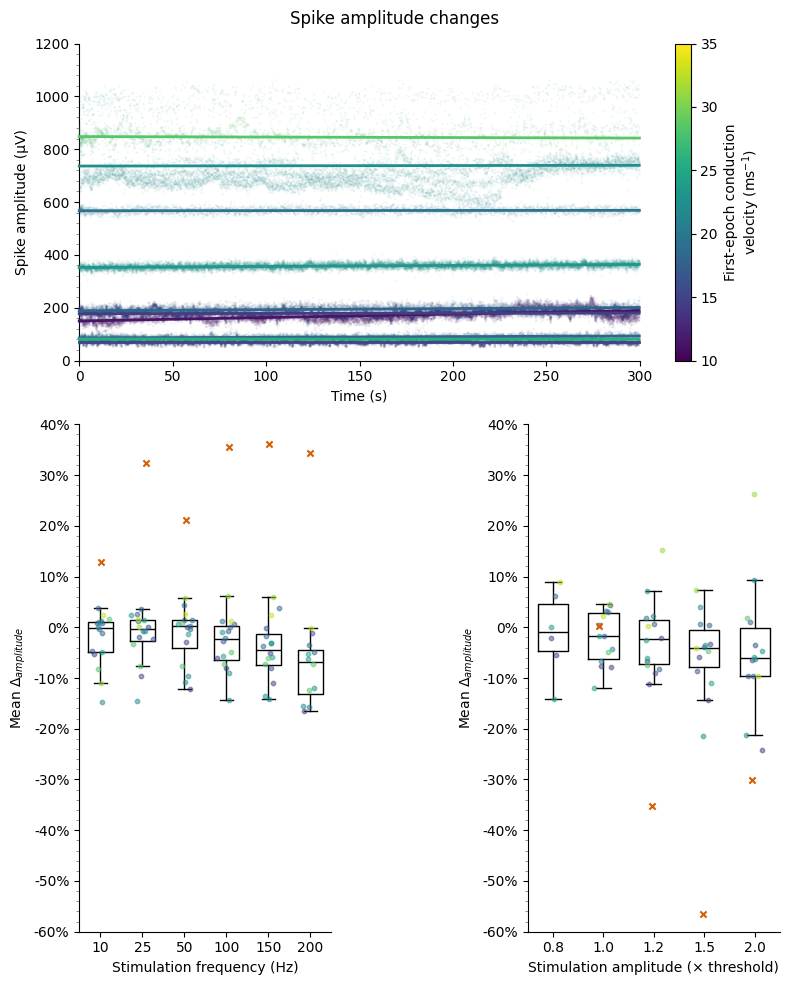

In [5]:
# User defined variables
amplitude_sweep_outliers = ['hff11_1']
latency_sweep_outliers = ['hff11_1']
first_n = None


### User does not need to modify below this line ###

# Figures 6-7
al_fitted_df, al_sweeps_df = hff_analysis.peak_property_changes(
    spikes_df,
    initial_properties,
    amplitude_sweep_outliers,
    latency_sweep_outliers,
    cv_norm,
    first_n,
    slowest_on_top,
    save_plots
)

if save_stats:
    al_fitted_name = '4_amplitude-latency-fitted-values.csv'
    al_sweeps_name = '4_amplitude-latency-sweeps-values.csv'
    try:
        al_fitted_df.to_csv(stats_folder+al_fitted_name)
        al_sweeps_df.to_csv(stats_folder+al_sweeps_name)
    except OSError:
        # Make directories if they don't exist
        pathlib.Path(stats_folder).mkdir(parents=True, exist_ok=True)
        al_fitted_df.to_csv(stats_folder+al_fitted_name)
        al_sweeps_df.to_csv(stats_folder+al_sweeps_name)

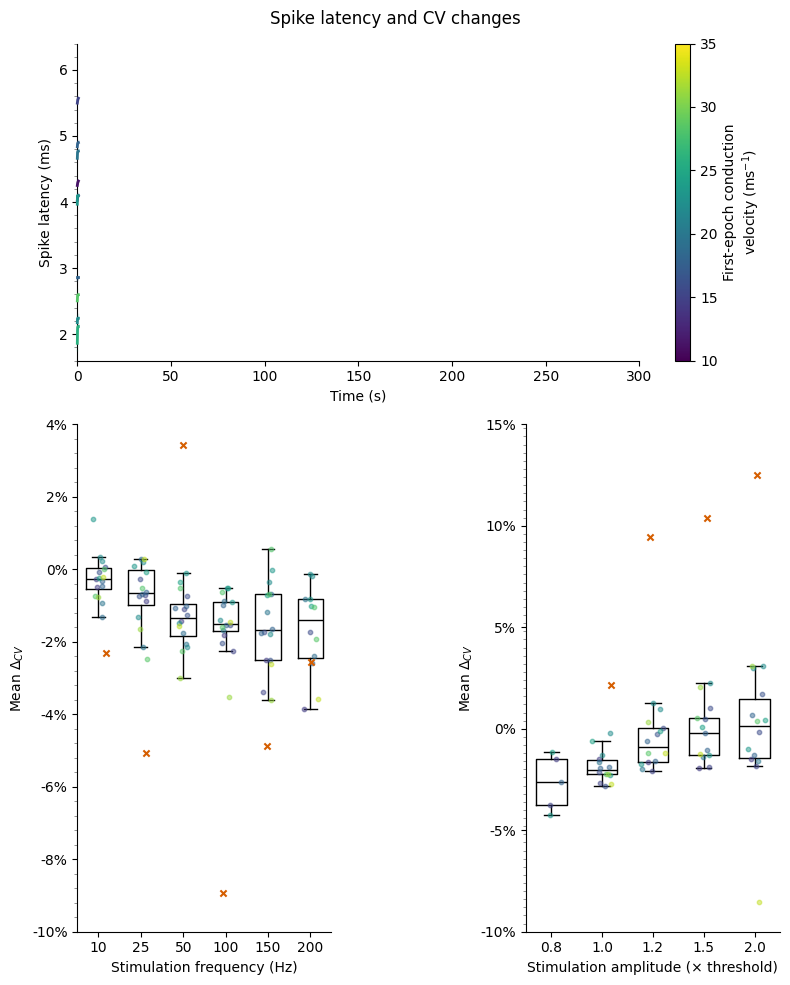

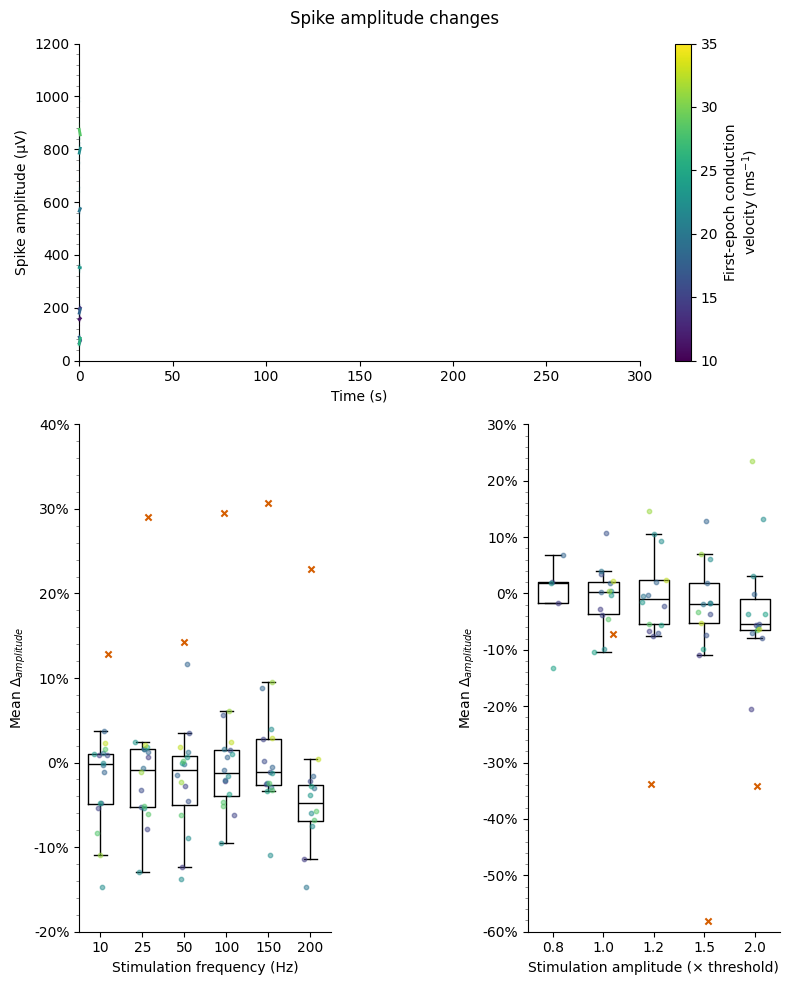

In [6]:
# User defined variables
amplitude_sweep_outliers = ['hff11_1']
latency_sweep_outliers = ['hff11_1']
first_n = 30


### User does not need to modify below this line ###

# Figures 6-7
al_fitted_df, al_sweeps_df = hff_analysis.peak_property_changes(
    spikes_df,
    initial_properties,
    amplitude_sweep_outliers,
    latency_sweep_outliers,
    cv_norm,
    first_n,
    slowest_on_top,
    save_plots
)

if save_stats:
    al_fitted_name = '4_amplitude-latency-fitted-values_first30.csv'
    al_sweeps_name = '4_amplitude-latency-sweeps-values_first30.csv'
    try:
        al_fitted_df.to_csv(stats_folder+al_fitted_name)
        al_sweeps_df.to_csv(stats_folder+al_sweeps_name)
    except OSError:
        # Make directories if they don't exist
        pathlib.Path(stats_folder).mkdir(parents=True, exist_ok=True)
        al_fitted_df.to_csv(stats_folder+al_fitted_name)
        al_sweeps_df.to_csv(stats_folder+al_sweeps_name)

  adjustable: {'box', 'datalim'}
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  anchor: (float, float) or {'C', 'SW', 'S', 'SE', 'E', 'NE', ...}
  animated: bool
  aspect: {'auto', 'equal'} or float
  autoscale_on: bool
  autoscalex_on: unknown
  autoscaley_on: unknown
  axes_locator: Callable[[Axes, Renderer], Bbox]
  axisbelow: bool or 'line'
  box_aspect: float or None
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  facecolor or fc: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  forward_navigation_events: bool or "auto"
  frame_on: bool
  gid: str
  in_layout: bool
  label: object
  mouseover: bool
  navigate: bool
  navigate_mode: unknown
  path_effects: list of `.AbstractPathEffect`
  picker: None or bool or float or c

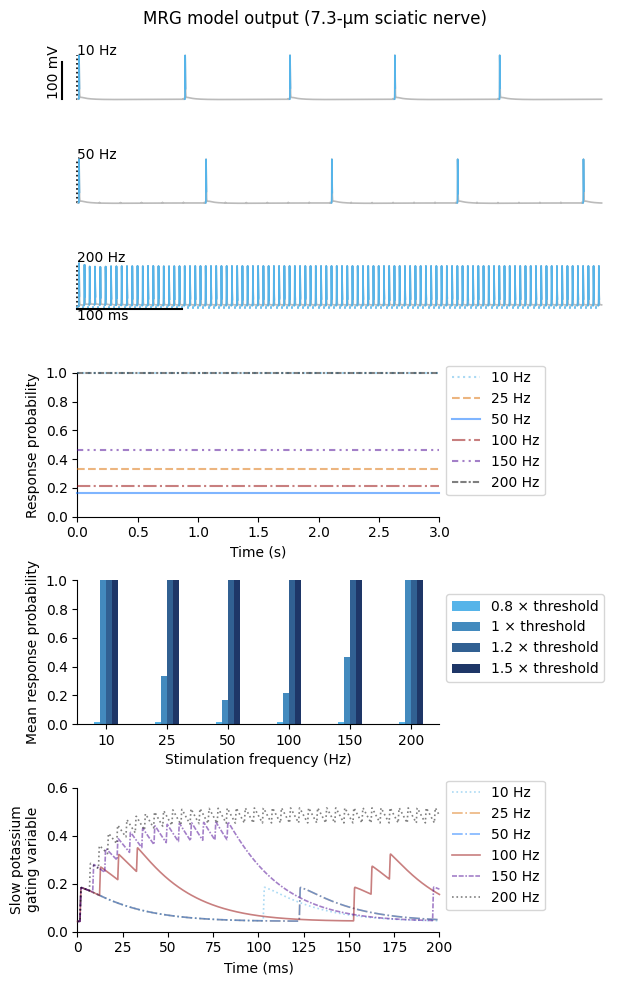

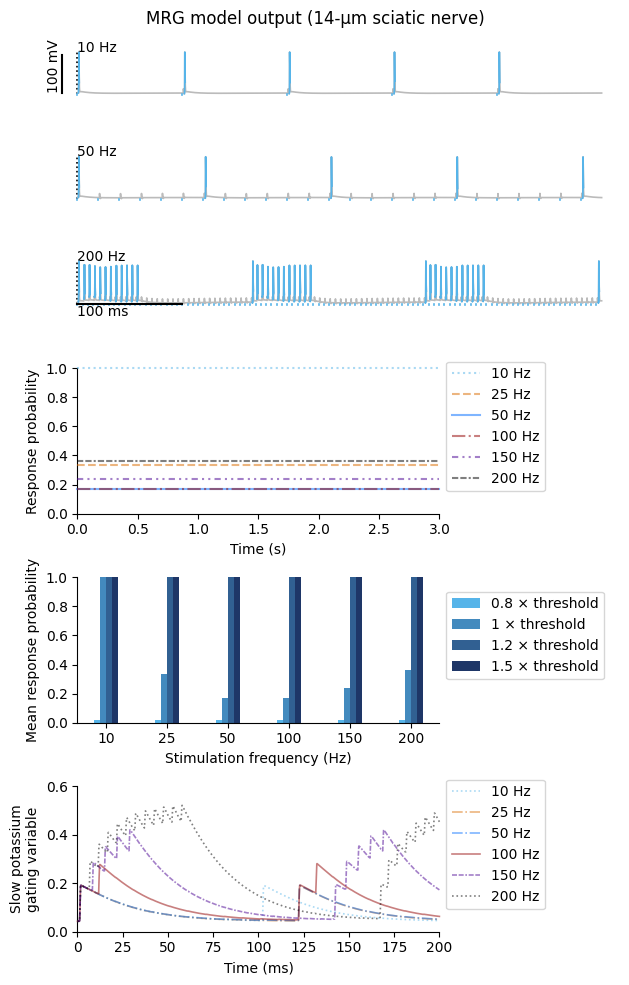

In [7]:
hff_analysis.model_output(10, 0.1, 100, save_plots)

RMSE (sural): 3.1102
RMSE (foot): 0.8921
RMSE (d1): 0.8312
RMSE (d2-4): 1.7150
RMSE (d5): 1.0194


c:\Users\Tom\OneDrive - UNSW\Documents\Code\Chapter 2 - Data Analysis HFF\src\hff_analysis\quantification.py:2926: RuntimeWarning: invalid value encountered in power
  popt, _pcov = curve_fit(lambda t, a, b: ((t-b)**(1/3))/a, x_data, y_data)
c:\Users\Tom\OneDrive - UNSW\Documents\Code\Chapter 2 - Data Analysis HFF\src\hff_analysis\quantification.py:2927: RuntimeWarning: invalid value encountered in power
  fit = lambda t: ((t-popt[1])**(1/3))/popt[0]


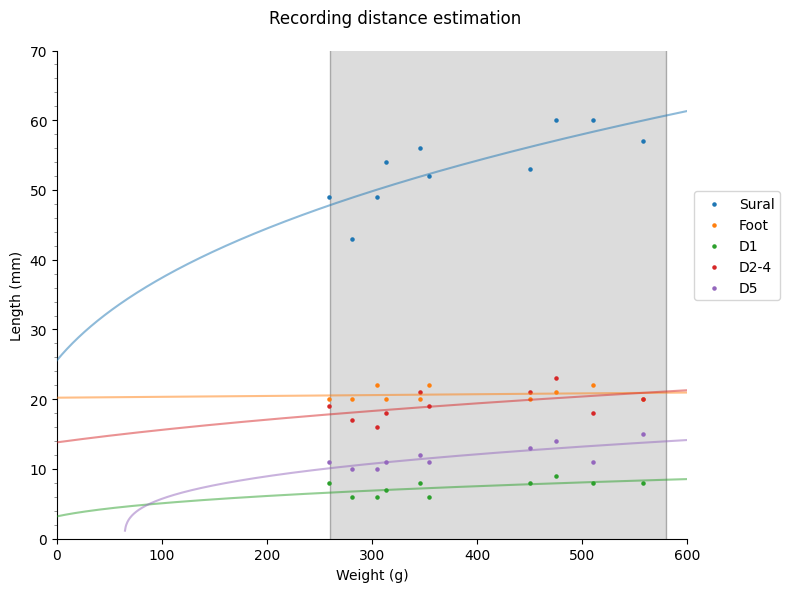

In [8]:
hff_analysis.plot_length_estimates(
    length_predictor,
    save_plots
)

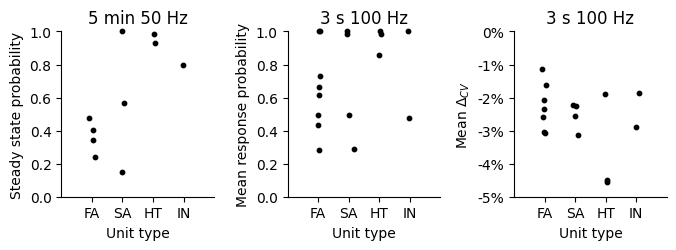

In [9]:
hff_analysis.unit_type_effects(save_plots)